## Discovering paths and verifying data structure


In [1]:
# ============================================
# Cell 1 — Setup, install deps, discover data
# ============================================
import os, sys, glob, subprocess, time, json, shutil
from pathlib import Path
from collections import defaultdict

print('Installing Python deps...')
subprocess.run(['pip', 'install', '-q',
                'plyfile', 'trimesh', 'networkx',
                'opencv-python', 'matplotlib'],
               check=False)

# Verify deps loaded
import importlib
for mod in ['plyfile', 'trimesh', 'networkx', 'cv2']:
    try:
        importlib.import_module(mod)
        print(f'  ✅ {mod}')
    except ImportError as e:
        print(f'  ❌ {mod}: {e}')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda')
print(f'\nDevice: {device} ({torch.cuda.get_device_name(0)})')

# Find attached preprocessed data (paths shift slightly based on how Kaggle mounts)
train_dirs = sorted(glob.glob('/kaggle/input/**/sunrgbd_pc_bbox_votes_50k_v1_train', recursive=True))
val_dirs   = sorted(glob.glob('/kaggle/input/**/sunrgbd_pc_bbox_votes_50k_v1_val',   recursive=True))
assert train_dirs and val_dirs, 'Preprocessed data not attached!'
SUNRGBD_BASE = str(Path(train_dirs[0]).parent)
print(f'\nData base: {SUNRGBD_BASE}')

ckpt_paths = sorted(glob.glob('/kaggle/input/**/pointnetpp_msg_domain_aug_best.pt', recursive=True))
assert ckpt_paths, 'domain_aug checkpoint not attached!'
DOMAIN_AUG_CKPT = ckpt_paths[0]
print(f'Backbone ckpt: {DOMAIN_AUG_CKPT}')

Installing Python deps...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 15.0 MB/s eta 0:00:00
  ✅ plyfile
  ✅ trimesh
  ✅ networkx
  ✅ cv2

Device: cuda (Tesla T4)

Data base: /kaggle/input/notebooks/vathsal05/sunrgbd-preprocessing-for-votenet
Backbone ckpt: /kaggle/input/datasets/vathsal05/multi-domain-finetune-inputs/pointnetpp_msg_domain_aug_best.pt


## Clone votenet, patch, compile pointnet2 CUDA ops 

In [2]:
# ============================================
# Cell 2 — Clone votenet + patch + compile pointnet2
# ============================================
REPO = Path('/kaggle/tmp/votenet')
if not REPO.exists():
    print('Cloning VoteNet...')
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/facebookresearch/votenet.git', str(REPO)],
                   check=True)
print(f'Repo at: {REPO}')

os.chdir(REPO / 'pointnet2')

# FIX 1: AT_CHECK → TORCH_CHECK (renamed in PyTorch 1.5+)
print('\nPatching AT_CHECK → TORCH_CHECK...')
subprocess.run(
    'find _ext_src -type f \\( -name "*.cpp" -o -name "*.cu" -o -name "*.h" \\) '
    '| xargs sed -i "s/AT_CHECK/TORCH_CHECK/g"',
    shell=True, check=True
)

# FIX 2: absolute paths in setup.py (ninja runs from build dir, relative paths fail)
print('Writing patched setup.py with absolute paths...')
with open('setup.py', 'w') as f:
    f.write('''import os
from setuptools import setup
from torch.utils.cpp_extension import BuildExtension, CUDAExtension
import glob

_ext_src_root = os.path.abspath("_ext_src")
_ext_sources = glob.glob("{}/src/*.cpp".format(_ext_src_root)) + glob.glob(
    "{}/src/*.cu".format(_ext_src_root)
)
setup(
    name="pointnet2",
    ext_modules=[
        CUDAExtension(
            name="pointnet2._ext",
            sources=_ext_sources,
            extra_compile_args={
                "cxx": ["-O2", "-I{}/include".format(_ext_src_root)],
                "nvcc": ["-O2", "-I{}/include".format(_ext_src_root)],
            },
        )
    ],
    cmdclass={"build_ext": BuildExtension},
)
''')

# Compile in-place (~3-5 min)
print('\nCompiling pointnet2 (3-5 min)...')
subprocess.run(['rm', '-rf', 'build', 'dist', 'pointnet2.egg-info'], check=False)
t0 = time.time()
result = subprocess.run(['python', 'setup.py', 'build_ext', '--inplace'],
                        capture_output=True, text=True)
print(f'Compile time: {(time.time()-t0)/60:.1f} min, return code: {result.returncode}')

# FIX 3: --inplace tries to copy to non-existent pointnet2/ subdir — do it manually
built = glob.glob('build/lib*/pointnet2/_ext*.so')
assert built, f'Compilation failed:\nSTDOUT tail:\n{result.stdout[-2000:]}\nSTDERR tail:\n{result.stderr[-2000:]}'
shutil.copy(built[0], os.path.basename(built[0]))
print(f'Copied {built[0]} → {os.path.basename(built[0])}')

# Verify CUDA ops work
sys.path.insert(0, str(REPO))
for mod in list(sys.modules.keys()):
    if 'pointnet2' in mod:
        del sys.modules[mod]
from pointnet2 import pointnet2_utils
x = torch.rand(2, 100, 3).cuda()
idx = pointnet2_utils.furthest_point_sample(x, 32)
print(f'✅ pointnet2 CUDA verified — FPS shape: {idx.shape}')

Cloning VoteNet...


Cloning into '/kaggle/tmp/votenet'...


Repo at: /kaggle/tmp/votenet

Patching AT_CHECK → TORCH_CHECK...
Writing patched setup.py with absolute paths...

Compiling pointnet2 (3-5 min)...
Compile time: 2.1 min, return code: 1
Copied build/lib.linux-x86_64-cpython-312/pointnet2/_ext.cpython-312-x86_64-linux-gnu.so → _ext.cpython-312-x86_64-linux-gnu.so
✅ pointnet2 CUDA verified — FPS shape: torch.Size([2, 32])


##  Build VoteNet model

In [3]:
# ============================================
# Cell 3 — Build VoteNet
# ============================================
for p in [str(REPO), str(REPO / 'utils'), str(REPO / 'models'), str(REPO / 'sunrgbd')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sunrgbd_detection_dataset import DC as SUNRGBD_CONFIG
from votenet import VoteNet

print('SUN RGB-D config:')
print(f'  num_class:        {SUNRGBD_CONFIG.num_class}')
print(f'  num_heading_bin:  {SUNRGBD_CONFIG.num_heading_bin}')
print(f'  num_size_cluster: {SUNRGBD_CONFIG.num_size_cluster}')

model = VoteNet(
    num_class=SUNRGBD_CONFIG.num_class,
    num_heading_bin=SUNRGBD_CONFIG.num_heading_bin,
    num_size_cluster=SUNRGBD_CONFIG.num_size_cluster,
    mean_size_arr=SUNRGBD_CONFIG.mean_size_arr,
    num_proposal=256,
    input_feature_dim=1,    # height feature
    vote_factor=1,
    sampling='vote_fps'
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'\nVoteNet built. Params: {n_params/1e6:.2f}M')

SUN RGB-D config:
  num_class:        10
  num_heading_bin:  12
  num_size_cluster: 10

VoteNet built. Params: 0.95M


## Load domain_aug backbone weights 

In [4]:
# ============================================
# Cell 4 — Backbone init from domain_aug
# ============================================
ckpt = torch.load(DOMAIN_AUG_CKPT, map_location=device, weights_only=False)
src_state = ckpt['model']

votenet_backbone = model.backbone_net
tgt_state = dict(votenet_backbone.state_dict())

n_loaded, used = 0, set()
new_state = dict(tgt_state)
for tgt_key, tgt_t in tgt_state.items():
    for src_key, src_t in src_state.items():
        if src_key not in used and src_t.shape == tgt_t.shape:
            new_state[tgt_key] = src_t.clone()
            used.add(src_key)
            n_loaded += 1
            break

votenet_backbone.load_state_dict(new_state)
pct = 100 * n_loaded / len(tgt_state)
print(f'Backbone init: {n_loaded}/{len(tgt_state)} ({pct:.0f}%) tensors from domain_aug')
print(f'Remaining {len(tgt_state) - n_loaded} stay random-init (new SA3/SA4/FP modules)')

Backbone init: 78/96 (81%) tensors from domain_aug
Remaining 18 stay random-init (new SA3/SA4/FP modules)


##  Dataset + DataLoader

In [5]:
# ============================================
# Cell 5 — Symlink data + build dataset/dataloader
# ============================================
ROOT = REPO / 'sunrgbd'
for split in ['train', 'val']:
    src = Path(SUNRGBD_BASE) / f'sunrgbd_pc_bbox_votes_50k_v1_{split}'
    dst = ROOT / f'sunrgbd_pc_bbox_votes_50k_v1_{split}'
    if dst.is_symlink() or dst.exists():
        if dst.is_symlink():
            dst.unlink()
    if not dst.exists():
        dst.symlink_to(src)
    print(f'  {dst.name} → {os.readlink(dst)}')

from sunrgbd_detection_dataset import SunrgbdDetectionVotesDataset

train_ds = SunrgbdDetectionVotesDataset(
    split_set='train', num_points=20000, use_color=False, use_height=True,
    use_v1=True, augment=True, scan_idx_list=None
)
val_ds = SunrgbdDetectionVotesDataset(
    split_set='val', num_points=20000, use_color=False, use_height=True,
    use_v1=True, augment=False, scan_idx_list=None
)
print(f'\nTrain: {len(train_ds)} scenes  Val: {len(val_ds)} scenes')

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True, drop_last=False)
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

  sunrgbd_pc_bbox_votes_50k_v1_train → /kaggle/input/notebooks/vathsal05/sunrgbd-preprocessing-for-votenet/sunrgbd_pc_bbox_votes_50k_v1_train
  sunrgbd_pc_bbox_votes_50k_v1_val → /kaggle/input/notebooks/vathsal05/sunrgbd-preprocessing-for-votenet/sunrgbd_pc_bbox_votes_50k_v1_val

Train: 5285 scenes  Val: 5050 scenes
Train batches: 660  Val batches: 632


## Loss and  optimizer and scheduler

In [6]:
# ============================================
# Cell 6 — Loss, optimizer, scheduler
# ============================================
from loss_helper import get_loss

EPOCHS = 100
LR_INIT = 1e-3
LR_MIN  = 1e-5

optimizer = AdamW(model.parameters(), lr=LR_INIT, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

LABEL_KEYS = ['center_label', 'heading_class_label', 'heading_residual_label',
              'size_class_label', 'size_residual_label', 'sem_cls_label',
              'box_label_mask', 'vote_label', 'vote_label_mask']

# Quick sanity: compute loss on one batch (verifies pipeline before long run)
print('Sanity-checking loss on one batch...')
batch = next(iter(train_loader))
batch_gpu = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
             for k, v in batch.items()}
model.train()
end_points = model(batch_gpu)
for k in LABEL_KEYS:
    end_points[k] = batch_gpu[k]
loss, _ = get_loss(end_points, SUNRGBD_CONFIG)
print(f'  Untrained loss: {loss.item():.4f}  (expected 25-30)')
assert not torch.isnan(loss), 'Loss is NaN — pipeline broken!'
print(f'\nReady. Epochs={EPOCHS}, batch={BATCH_SIZE}, LR={LR_INIT}→{LR_MIN}')

Sanity-checking loss on one batch...
  Untrained loss: 29.9372  (expected 25-30)

Ready. Epochs=100, batch=8, LR=0.001→1e-05


/kaggle/tmp/votenet/models/loss_helper.py:155: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  heading_label_one_hot = torch.cuda.FloatTensor(batch_size, heading_class_label.shape[1], num_heading_bin).zero_()


## Training loop

In [7]:
# ============================================
# Cell 7 — Training loop (4-8 hours for 100 epochs)
# ============================================
OUT_DIR = Path('/kaggle/working')
OUT_DIR.mkdir(exist_ok=True)
best_val_loss = float('inf')
history = []

def run_epoch(loader, training):
    model.train() if training else model.eval()
    sums = defaultdict(float)
    n = 0
    for batch in loader:
        batch_gpu = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
        if training:
            optimizer.zero_grad(set_to_none=True)
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            end_points = model(batch_gpu)
            for k in LABEL_KEYS:
                end_points[k] = batch_gpu[k]
            loss, end_points = get_loss(end_points, SUNRGBD_CONFIG)
        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        sums['loss'] += loss.item()
        for k in ['vote_loss', 'objectness_loss', 'center_loss', 'box_loss', 'sem_cls_loss']:
            if k in end_points:
                sums[k] += end_points[k].item()
        n += 1
    return {k: v / n for k, v in sums.items()}


for ep in range(EPOCHS):
    t0 = time.time()
    train_metrics = run_epoch(train_loader, training=True)
    cur_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    val_metrics = {}
    if (ep + 1) % 5 == 0 or ep == EPOCHS - 1:
        val_metrics = run_epoch(val_loader, training=False)

    val_str = f'  val_loss={val_metrics.get("loss", float("nan")):.4f}' if val_metrics else ''
    print(f'Epoch {ep+1:3d}/{EPOCHS}  lr={cur_lr:.6f}  '
          f'train_loss={train_metrics["loss"]:.4f}{val_str}  ({time.time()-t0:.0f}s)',
          flush=True)

    history.append({'epoch': ep+1, 'lr': cur_lr,
                    **{f'train_{k}': v for k, v in train_metrics.items()},
                    **{f'val_{k}': v for k, v in val_metrics.items()}})

    if val_metrics and val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save({'epoch': ep+1, 'model': model.state_dict(),
                    'val_loss': best_val_loss},
                   OUT_DIR / 'votenet_sunrgbd_best.pt')
        print(f'   --> New best val_loss={best_val_loss:.4f}', flush=True)

    if (ep + 1) % 5 == 0 or ep == EPOCHS - 1:
        with open(OUT_DIR / 'training_history.json', 'w') as f:
            json.dump(history, f, indent=2)

torch.save({'epoch': EPOCHS, 'model': model.state_dict()},
           OUT_DIR / 'votenet_sunrgbd_last.pt')
print(f'\nDone. Best val_loss: {best_val_loss:.4f}')

Epoch   1/100  lr=0.001000  train_loss=15.6068  (275s)
Epoch   2/100  lr=0.001000  train_loss=13.0858  (273s)
Epoch   3/100  lr=0.000999  train_loss=12.3310  (273s)
Epoch   4/100  lr=0.000998  train_loss=11.7411  (273s)
Epoch   5/100  lr=0.000996  train_loss=11.2795  val_loss=12.0247  (504s)
   --> New best val_loss=12.0247
Epoch   6/100  lr=0.000994  train_loss=10.8090  (273s)
Epoch   7/100  lr=0.000991  train_loss=10.4065  (273s)
Epoch   8/100  lr=0.000988  train_loss=10.2261  (273s)
Epoch   9/100  lr=0.000984  train_loss=9.9173  (273s)
Epoch  10/100  lr=0.000980  train_loss=9.7476  val_loss=10.7676  (393s)
   --> New best val_loss=10.7676
Epoch  11/100  lr=0.000976  train_loss=9.5185  (273s)
Epoch  12/100  lr=0.000971  train_loss=9.3449  (274s)
Epoch  13/100  lr=0.000965  train_loss=9.1034  (273s)
Epoch  14/100  lr=0.000959  train_loss=8.8906  (274s)
Epoch  15/100  lr=0.000953  train_loss=8.9393  val_loss=9.3441  (394s)
   --> New best val_loss=9.3441
Epoch  16/100  lr=0.000946  tra

In [3]:
import json
import matplotlib.pyplot as plt

PATH = '/Users/dosvatsky/3D Object Detection/checkpoints/training_history3.json'

with open(PATH) as f:
    hist = json.load(f)

# How many entries and what are the keys?
print(f'Total entries: {len(hist)}')
print(f'\nFirst entry keys: {list(hist[0].keys())}')
print(f'Entry index 4 (epoch 5) keys: {list(hist[4].keys()) if len(hist) > 4 else "N/A"}')
print(f'Last entry keys: {list(hist[-1].keys())}')

print(f'\nFirst entry full content:')
for k, v in hist[0].items():
    print(f'  {k}: {v}')
print(f'\nLast entry full content:')
for k, v in hist[-1].items():
    print(f'  {k}: {v}')

# Find any entries with val data
val_keys_found = set()
for h in hist:
    for k in h.keys():
        if k.startswith('val'):
            val_keys_found.add(k)
print(f'\nAll val-related keys found: {val_keys_found}')

n_with_val = sum(1 for h in hist if 'val_loss' in h)
print(f'\nEntries with val_loss: {n_with_val} / {len(hist)}')

Total entries: 100

First entry keys: ['epoch', 'lr', 'train_loss', 'train_vote_loss', 'train_objectness_loss', 'train_center_loss', 'train_box_loss', 'train_sem_cls_loss']
Entry index 4 (epoch 5) keys: ['epoch', 'lr', 'train_loss', 'train_vote_loss', 'train_objectness_loss', 'train_center_loss', 'train_box_loss', 'train_sem_cls_loss', 'val_loss', 'val_vote_loss', 'val_objectness_loss', 'val_center_loss', 'val_box_loss', 'val_sem_cls_loss']
Last entry keys: ['epoch', 'lr', 'train_loss', 'train_vote_loss', 'train_objectness_loss', 'train_center_loss', 'train_box_loss', 'train_sem_cls_loss', 'val_loss', 'val_vote_loss', 'val_objectness_loss', 'val_center_loss', 'val_box_loss', 'val_sem_cls_loss']

First entry full content:
  epoch: 1
  lr: 0.001
  train_loss: 15.606806509422533
  train_vote_loss: 0.6633097761959741
  train_objectness_loss: 0.107964699091672
  train_center_loss: 0.13132964839425051
  train_box_loss: 0.7108092831842827
  train_sem_cls_loss: 1.3257924036997737

Last entry f

## Evaluating Model

Final train_loss: 5.8813  (epoch 100)
Final val_loss:   6.5325  (epoch 100)
Best val_loss:    6.5325  at epoch 100

Best val_loss breakdown (epoch 100):
  val_vote_loss             0.3233
  val_objectness_loss       0.0783
  val_center_loss           0.0474
  val_box_loss              0.2459
  val_sem_cls_loss          0.4492


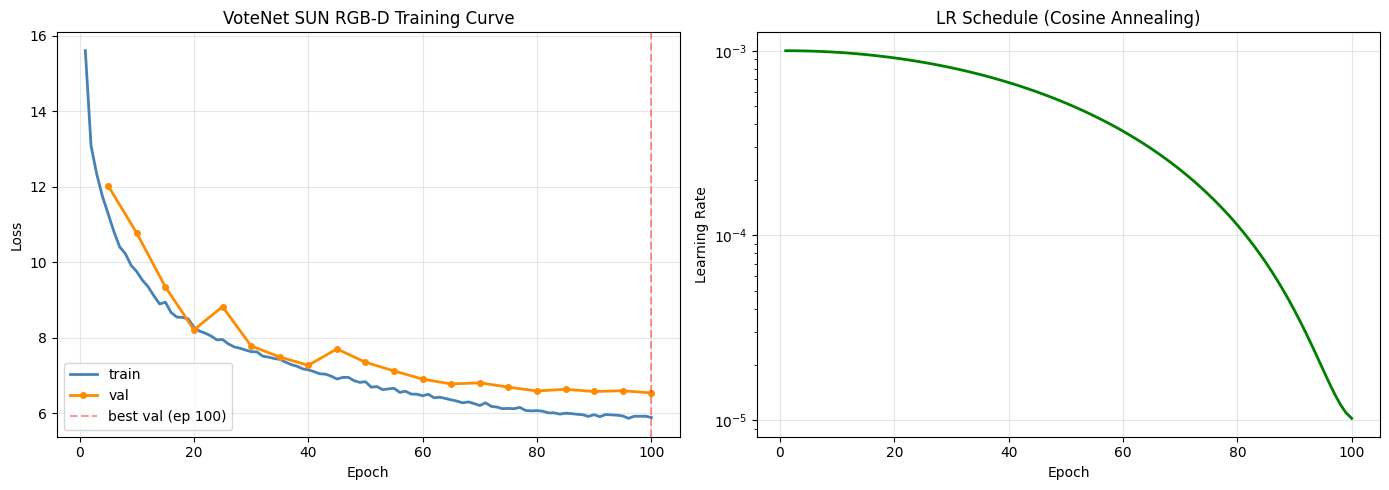

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np

PATH = '/Users/dosvatsky/3D Object Detection/checkpoints/training_history3.json'

with open(PATH) as f:
    hist = json.load(f)

# All entries have train data
train_epochs = [h['epoch'] for h in hist]
train_loss   = [h['train_loss'] for h in hist]
train_lr     = [h['lr'] for h in hist]

# Only some entries have val data — filter properly
val_entries  = [h for h in hist if 'val_loss' in h]
val_epochs   = [h['epoch'] for h in val_entries]
val_loss     = [h['val_loss'] for h in val_entries]

# Find best
best_idx = int(np.argmin(val_loss))
best_epoch = val_epochs[best_idx]
best_val = val_loss[best_idx]

print('=' * 60)
print(f'Final train_loss: {train_loss[-1]:.4f}  (epoch {train_epochs[-1]})')
print(f'Final val_loss:   {val_loss[-1]:.4f}  (epoch {val_epochs[-1]})')
print(f'Best val_loss:    {best_val:.4f}  at epoch {best_epoch}')
print('=' * 60)

# Per-component breakdown of the BEST epoch
print(f'\nBest val_loss breakdown (epoch {best_epoch}):')
best_entry = val_entries[best_idx]
for k in ['val_vote_loss', 'val_objectness_loss', 'val_center_loss',
          'val_box_loss', 'val_sem_cls_loss']:
    if k in best_entry:
        print(f'  {k:25s} {best_entry[k]:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_epochs, train_loss, label='train', linewidth=2, color='steelblue')
axes[0].plot(val_epochs, val_loss, label='val', marker='o', markersize=4,
             linewidth=2, color='darkorange')
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.4,
                label=f'best val (ep {best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('VoteNet SUN RGB-D Training Curve')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(train_epochs, train_lr, color='green', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning Rate')
axes[1].set_title('LR Schedule (Cosine Annealing)')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('/Users/dosvatsky/3D Object Detection/votenet_training_curve.png',
            dpi=120, bbox_inches='tight')
plt.show()